Import all the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Create the scatterplot

In [2]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


This plot can give you an immediate sense of whether linear regression is suitable for the given data

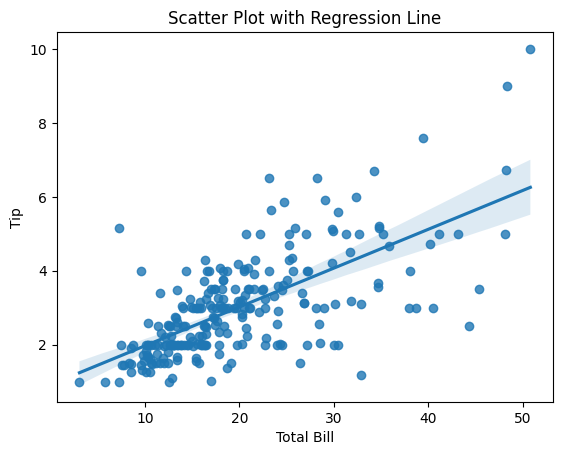

In [3]:
sns.regplot(x='total_bill', y='tip', data=tips)
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter Plot with Regression Line')
plt.show()

Implementation of Regularization Techniques

In [4]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [5]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

Data Splitting into independent features and target variable

In [6]:
X, y = fetch_california_housing(return_X_y=True)

# independent feature
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [7]:
# target feature
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [9]:
X.shape

(20640, 8)

In [10]:
y.shape

(20640,)

Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)
X_train

array([[   2.6618    ,   19.        ,    4.66666667, ...,    3.46362098,
          33.88      , -118.28      ],
       [   3.9261    ,   12.        ,    5.65730337, ...,    2.88483146,
          35.63      , -117.76      ],
       [   2.532     ,   39.        ,    3.73425693, ...,    3.32241814,
          34.04      , -118.32      ],
       ...,
       [   6.        ,   40.        ,    5.99019608, ...,    2.45424837,
          37.53      , -122.3       ],
       [   5.1408    ,   33.        ,    5.35986159, ...,    3.04844291,
          34.27      , -118.47      ],
       [   1.5517    ,   31.        ,    3.11083123, ...,    2.05541562,
          32.76      , -117.09      ]])

In [12]:
y_train

array([1.797, 1.013, 1.727, ..., 3.842, 2.229, 1.225])

In [13]:
X_train.shape

(16512, 8)

In [14]:
X_test.shape

(4128, 8)

EDA => Statistical Module => Task to perform at your end

Data Leakage

Normalization of data

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
X_train_scaled

array([[-6.39313890e-01, -7.70123468e-01, -3.18448077e-01, ...,
         3.12799921e-02, -8.18307745e-01,  6.42275354e-01],
       [ 2.55369484e-02, -1.32842869e+00,  9.00311043e-02, ...,
        -1.86339026e-02,  2.97361004e-05,  9.01327246e-01],
       [-7.07571138e-01,  8.25034301e-01, -7.02917949e-01, ...,
         1.91028816e-02, -7.43488318e-01,  6.22348286e-01],
       ...,
       [ 1.11612791e+00,  9.04792190e-01,  2.27296098e-01, ...,
        -5.57667090e-02,  8.88510430e-01, -1.36039504e+00],
       [ 6.64304894e-01,  3.46486970e-01, -3.26160516e-02, ...,
        -4.52430976e-03, -6.35935392e-01,  5.47621779e-01],
       [-1.22307638e+00,  1.86971194e-01, -9.59981326e-01, ...,
        -9.01614158e-02, -1.34204373e+00,  1.23510564e+00]])

In [17]:
X_test_scaled

array([[ 2.86260705e-01,  4.26244859e-01,  1.69578464e-01, ...,
         3.46072137e-02, -5.75144608e-01,  2.93551655e-01],
       [ 1.22103793e+00,  5.85760636e-01,  3.59063490e-01, ...,
        -4.55110319e-02,  8.18367217e-01, -1.25577793e+00],
       [ 3.30009692e+00, -2.12600757e+00,  1.84207456e+00, ...,
         5.84330242e-02, -9.30536885e-01,  9.71071986e-01],
       ...,
       [ 1.36307401e+00, -1.48794446e+00,  7.33317830e-01, ...,
         3.61134621e-02, -1.24384324e+00,  1.21517858e+00],
       [ 3.99637151e-01, -5.23024719e-02,  3.47527685e-01, ...,
         2.32720415e-02,  1.10829250e+00, -1.22090556e+00],
       [-9.16129109e-01,  1.22382374e+00, -3.40511886e-01, ...,
        -3.02836919e-03, -7.62193175e-01,  6.37293587e-01]])

Model Training

Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [25]:
model.coef_

array([ 0.83215514,  0.11519221, -0.2633912 ,  0.31621969, -0.00115802,
       -0.03990048, -0.90741623, -0.87609073])

In [26]:
model.intercept_

np.float64(2.0677633024468007)

Lasso Regression (L1 Regularization)

In [28]:
from sklearn.linear_model import Lasso
model_lasso = Lasso()

In [29]:
model_lasso.fit(X_train_scaled, y_train)

Lasso()

In [45]:
model_lasso.coef_

array([ 0.,  0.,  0., -0., -0., -0., -0., -0.])

Ridge Regression (L2 Regualarization)

In [22]:
from sklearn.linear_model import Ridge
model_ridge = Ridge()

In [30]:
model_ridge.fit(X_train_scaled, y_train)

Ridge()

Elastic Net Regression (Combination of L1 and L2)

In [23]:
from sklearn.linear_model import ElasticNet
model_elastic_net = ElasticNet()

In [31]:
model_elastic_net.fit(X_train_scaled, y_train)

ElasticNet()

Model Prediction

In [32]:
y_pred = model.predict(X_test_scaled)
print(y_pred)

[2.55823281 3.35684836 4.09751962 ... 2.80867915 2.38870762 1.61280809]


In [33]:
y_pred_Lasso = model_lasso.predict(X_test_scaled)
print(y_pred_Lasso)

[2.0677633 2.0677633 2.0677633 ... 2.0677633 2.0677633 2.0677633]


In [34]:
y_pred_Ridge = model_ridge.predict(X_test_scaled)
print(y_pred_Ridge)

[2.55805966 3.35658646 4.0975895  ... 2.80868816 2.38863631 1.61282596]


In [35]:
y_pred_Elastic = model_elastic_net.predict(X_test_scaled)
print(y_pred_Elastic)

[2.12337531 2.30497493 2.70887472 ... 2.33256835 2.145401   1.88978646]


Model Evaluation

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print(mean_squared_error(y_test, y_pred))

0.5347838950335047


In [37]:
mean_absolute_error(y_test, y_pred)

0.5278504031670417

In [38]:
r2_score(y_test, y_pred)

0.6084415600235556

In [39]:
mean_squared_error(y_test, y_pred_Lasso)

1.3657988826860425

In [40]:
r2_score(y_test, y_pred_Lasso)

-1.156503153976196e-05

Testing Set Error

In [43]:
# linear regression
print(mean_squared_error(y_test, y_pred))

0.5347838950335047


In [46]:
y_pred_train = model.predict(X_train_scaled)

Training Set Error

In [47]:
print(mean_squared_error(y_train, y_pred_train))

0.5231785604715513


There is no overfitting, so no need to further go for regularization techniques

In [42]:
# lasso regression
print(mean_squared_error(y_test, y_pred_Lasso))

1.3657988826860425


In [41]:
# ridge regression
print(mean_squared_error(y_test, y_pred_Ridge))

0.5347633787931915


In [44]:
# elastic net regression
print(mean_squared_error(y_test, y_pred_Elastic))

1.092171083664887
